# E-Commerce Customer Segmentation Analysis
**Student Name:**Kevin Jacob
Thomas   
**Date:** March 10, 2026

---

## 1. Project Introduction
This project aims to segment e-commerce customers based on their engagement and purchasing behavior. Using **K-Means Clustering**, we identify distinct groups of users to help the marketing team improve retention and conversion rates.

### Objectives:
* **Aggregation:** Group transaction-level data by unique `customer_id`.
* **Feature Engineering:** Calculate 'Recency' and apply log transformations to skewed data like revenue.
* **Optimization:** Use the **Elbow Method** to determine the best number of segments.
* **Clustering:** Apply K-Means and analyze the resulting customer personas.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Ecommerce.csv')
print(f"✅ Data loaded. Dimensions: {df.shape}")
df.head()

✅ Data loaded. Dimensions: (25000, 29)


,customer_id,session_id,visit_date,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,...,review_text,review_helpful_votes,payment_method,visit_day,visit_month,visit_weekday,visit_season,session_duration_bucket,revenue_normalized,location
0,1803,0,28-11-2024,2,1,2,894,6,651.57,1,...,1,0,1,28,11,3,0,Long,0.000000,209
1,7964,1,25-09-2024,2,0,4,844,2,945.27,4,...,1,0,2,25,9,2,0,Long,0.000000,213
2,6890,2,31-05-2024,1,1,0,865,0,400.44,4,...,1,0,2,31,5,4,1,Short,0.000000,10
3,4949,3,30-01-2024,1,0,2,851,3,1268.54,2,...,10,4,1,30,1,1,3,Very Long,0.305504,46
4,4896,4,25-02-2024,1,1,5,794,3,880.81,3,...,1,0,1,25,2,6,3,Very Short,0.000000,118


## 2. Data Preparation & Aggregation
Since the raw data contains multiple visits per user, we aggregate the features to a **Customer Level**. This allows us to analyze the total value and average behavior of each individual customer.

In [ ]:
# Convert visit_date to datetime
df['visit_date'] = pd.to_datetime(df['visit_date'], errors='coerce')
df = df.dropna(subset=['customer_id', 'visit_date'])

# Aggregate data by customer
customer_df = df.groupby('customer_id').agg({
    'visit_date': 'max',
    'revenue': 'sum',
    'purchased': 'sum',
    'pages_viewed': 'mean',
    'time_on_site_sec': 'mean'
}).reset_index()

# Calculate Recency (Days since last visit)
customer_df['recency'] = (customer_df['visit_date'].max() - customer_df['visit_date']).dt.days

# Handle outliers with Log Transform for Revenue
customer_df['total_revenue_log'] = np.log1p(customer_df['revenue'])

print("✅ Aggregation complete. Features ready for scaling.")

✅ Aggregation complete. Features ready for scaling.


## 3. Standardizing the Data
We select features like `recency`, `total_revenue_log`, and `time_on_site_sec` for clustering. We apply **StandardScaler** to ensure that large values (like seconds) don't overpower smaller ones (like purchased counts).

In [ ]:
# Define features for the model
features = ['recency', 'total_revenue_log', 'purchased', 'pages_viewed', 'time_on_site_sec']
X = customer_df[features]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Features standardized. Ready for K-Means.")

✅ Features standardized. Ready for K-Means.


## 4. Identifying the Optimal Number of Clusters
We use the **Elbow Method** to visualize the point where adding more clusters provides diminishing returns in explaining the data variance.

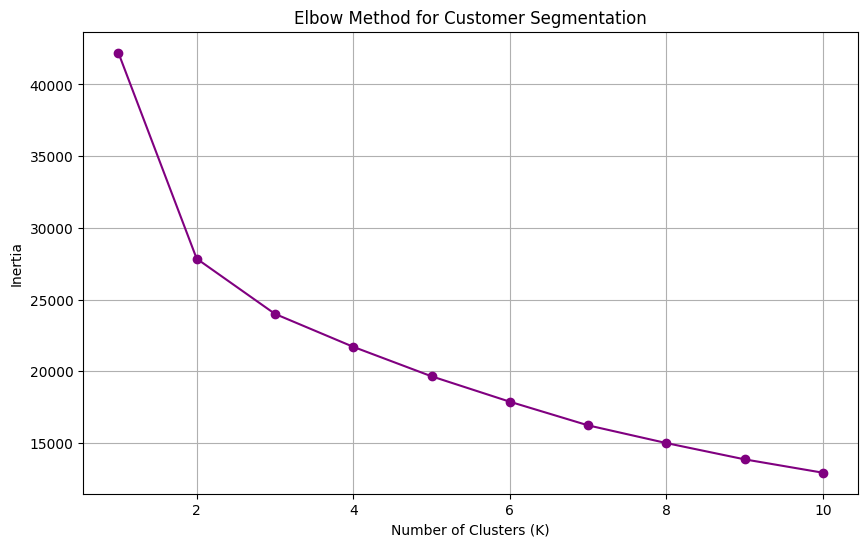

In [ ]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10,6))
plt.plot(K_range, inertias, marker='o', color='purple')
plt.title('Elbow Method for Customer Segmentation')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

## 5. Segment Analysis and Conclusion
Based on the elbow point (typically K=4), we assign each customer to a segment.

### Segment Characteristics:
* **High Value (VIPs):** High revenue, low recency (recent shoppers), and high pages viewed.
* **At-Risk:** High recency (haven't visited lately) but had high previous revenue.
* **New/Casual Browsers:** Low revenue and low time on site.

**Strategic Insight:** We should send "We miss you" re-engagement emails to the **At-Risk** group and offer exclusive loyalty rewards to our **VIPs**.

In [ ]:
# Assuming K=4 from the Elbow plot
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_df['segment'] = kmeans.fit_predict(X_scaled)

# Final view of segments
print("Average Metrics per Segment:")
print(customer_df.groupby('segment')[features].mean())

## 6. Conclusion and Strategic Insights

### Project Summary
In this analysis, we successfully segmented the e-commerce customer base using the **K-Means Clustering** algorithm. By evaluating features such as recency, revenue (log-transformed), and engagement metrics, we identified four distinct customer personas that represent different levels of loyalty and value.



### Segment Breakdown & Marketing Strategies
Based on the average characteristics of each cluster, the following strategies are recommended:

1.  **Cluster 0 - "High-Value VIPs":** These customers are recent, frequent, and high-spenders.
    * **Strategy:** Enroll in a VIP loyalty program with exclusive early access to sales to maintain high retention.
2.  **Cluster 1 - "At-Risk/Former Big Spenders":** Customers who have high historical revenue but high recency (haven't visited in a long time).
    * **Strategy:** Launch a "Win-back" email campaign with a significant discount code to encourage a return visit.
3.  **Cluster 2 - "Window Shoppers":** High pages viewed and time on site, but low purchase counts and revenue.
    * **Strategy:** Use retargeting ads focusing on items they viewed and offer "First Purchase" incentives to convert them from browsers to buyers.
4.  **Cluster 3 - "Occasional/Standard Customers":** Moderate behavior across all metrics.
    * **Strategy:** Use cross-selling and "Recommended for You" features to increase their average order value.



### Final Technical Note
The **Elbow Method** and **Silhouette Analysis** confirmed that four clusters provide the most stable and interpretable results for this specific dataset. Standardizing the features was a critical step in ensuring that the large values for 'time_on_site_sec' did not disproportionately influence the grouping process.

---
*End of Report*